Código adaptado de:

[1] Documentação do PyTorch: [Learn the Basics](https://docs.pytorch.org/tutorials/beginner/basics/intro.html)

# Laboratório 0: Tutorial Pytorch

# Importações

In [1]:
!pip install torchinfo
!pip install torch
!pip install torchvision
!pip install matplotlib

In [2]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import DataLoader     # Importa o DataLoader, que facilita o carregamento de dados em mini-lotes durante o treinamento
from torchvision import datasets            # Importa o módulo de conjuntos de dados do torchvision, que fornece acesso a conjuntos de dados populares como MNIST, CIFAR, etc. para visão computacional
from torchvision.transforms import ToTensor # Importa a transformação ToTensor, que converte imagens PIL ou NumPy arrays em tensores PyTorch
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import matplotlib.pyplot as plt             # Importa o módulo pyplot do Matplotlib, usado para criar gráficos e exibir imagens no notebook

In [3]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

# Define o dispositivo de hardware para execução: usa acelerador (GPU/TPU) se disponível; caso contrário, usa a CPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Usando o dispositivo: {device}") # Exibe qual dispositivo está sendo utilizado


Usando o dispositivo: mps


# Tarefa

Utilize a base de dados [**CIFAR-10**](https://www.cs.toronto.edu/~kriz/cifar.html) e desenvolva um classificador de imagens em **PyTorch**.

---

## 1. Preparação da base de dados

Carregue a base [**CIFAR-10**](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) usando `torchvision.datasets`.

Seu código deve:

- separar conjunto de treinamento e teste;
- usar `DataLoader` para ambos;
- transformar as imagens em tensores;
- exibir algumas imagens da base com seus respectivos rótulos.

---

## 2. Construção do modelo

Implemente uma rede neural convolucional contendo:

- **camadas convolucionais**;
- **funções de ativação ReLU**;
- **camadas de pooling**;
- **normalização em lote** ([`BatchNorm2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html));
- **camadas totalmente conectadas** na parte final.

A rede deve conter pelo menos:

- 2 blocos convolucionais;
- cada bloco com convolução + batch normalization + ReLU;
- pelo menos 1 operação de pooling após blocos convolucionais;
- pelo menos 1 camada totalmente conectada antes da camada de saída;
- camada de saída compatível com as 10 classes do CIFAR-10.

Uma organização possível é:

- **Bloco 1:** `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d`
- **Bloco 2:** `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d`
- **Classificador:** `Flatten -> Linear -> ReLU -> Linear`

---

## 3. Treinamento do modelo

Treine inicialmente um modelo-base com a seguinte configuração:

- otimizador: `Adam`;
- função de perda: `CrossEntropyLoss`;
- número de épocas: `15`;
- taxa de aprendizagem inicial: `1e-3`;
- tamanho do lote inicial: `64`.

Durante o treinamento, registre:

- perda de treinamento por época;
- acurácia de treinamento por época;
- perda no teste por época;
- acurácia no teste por época.

Ao final salve o modelo e apresente:

- a acurácia final no conjunto de teste;
- um gráfico da perda ao longo das épocas;
- um gráfico da acurácia ao longo das épocas.

---

## 4. Observações

- Utilize **PyTorch** e implemente a rede com `nn.Module`.
- Não utilize modelos pré-treinados.
- Organize o código em seções claras no notebook.
- Comente o código de forma objetiva.

# Resolução da Tarefa
Utilize a base de dados [**CIFAR-10**](https://www.cs.toronto.edu/~kriz/cifar.html) e desenvolva um classificador de imagens em **PyTorch**.


## 1. Preparação da base de dados

Carregue a base [**CIFAR-10**](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) usando `torchvision.datasets`.

Seu código deve:

- separar conjunto de treinamento e teste;
- usar `DataLoader` para ambos;
- transformar as imagens em tensores;
- exibir algumas imagens da base com seus respectivos rótulos.

In [4]:
# Baixa os dados de treinamento a partir de conjuntos de dados públicos
cifar_training_data = datasets.CIFAR10(
    root="data",             # Diretório onde os dados serão armazenados
    train=True,              # Indica que este é o conjunto de dados de treinamento
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=ToTensor(),    # Aplica a transformação ToTensor para converter as imagens em tensores
)

# Baixa os dados de teste a partir de conjuntos de dados públicos
cifar_test_data = datasets.CIFAR10(
    root="data",             # Diretório onde os dados serão armazenados
    train=False,             # Indica que este é o conjunto de dados de teste
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=ToTensor(),    # Aplica a transformação ToTensor para converter as imagens em tensores
)


In [5]:
batch_size = 64                                                                     # Define o tamanho do lote, ou seja, quantas amostras serão processadas por vez
cifar_train_dataloader = DataLoader(cifar_training_data, batch_size=batch_size, shuffle=True)   # Cria o DataLoader para o conjunto de treinamento
cifar_test_dataloader = DataLoader(cifar_test_data, batch_size=batch_size, shuffle=True)        # Cria o DataLoader para o conjunto de teste

# Itera sobre o DataLoader de teste para visualizar as formas dos dados
for X, y in cifar_test_dataloader:
    # Exibe a forma e o tipo do tensor de imagens
    # N = tamanho do lote, C = canais (1 para imagens em tons de cinza), H = altura, W = largura
    print(f"Forma de X [N, C, H, W]: {X.shape}, Tipo de dados em X: {X.dtype}")

    # Exibe a forma e o tipo dos rótulos (labels)
    print(f"Forma de y: {y.shape}, Tipo de dados em y: {y.dtype}")

    break  # Encerra o loop após a primeira iteração, apenas para inspeção dos dados

Forma de X [N, C, H, W]: torch.Size([64, 3, 32, 32]), Tipo de dados em X: torch.float32
Forma de y: torch.Size([64]), Tipo de dados em y: torch.int64


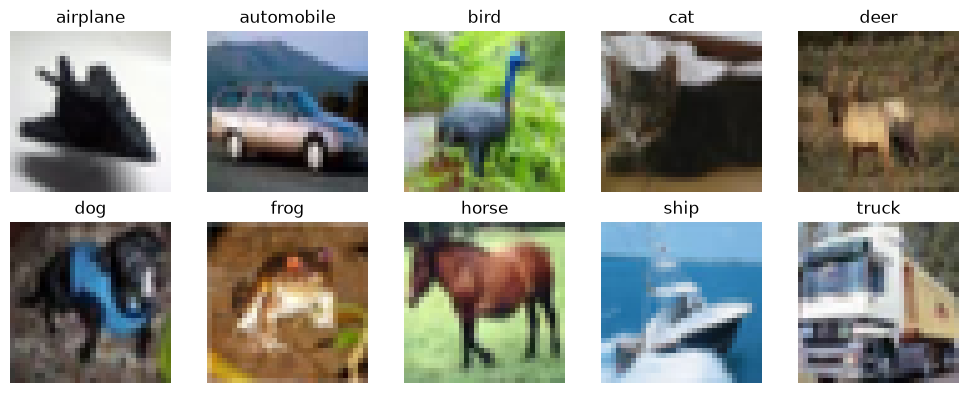

In [6]:
# Lista com os nomes das classes do conjunto de dados Fashion MNIST, na mesma ordem dos índices
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# Dicionário para armazenar um exemplo por classe
examples = {}

# Itera sobre o dataset até obter um exemplo de cada classe
for img, label in cifar_training_data:
    if label not in examples:
        examples[label] = img  # remove o canal extra (1, 28, 28) -> (28, 28)
    if len(examples) == 10:
        break

# Plota os exemplos
plt.figure(figsize=(10, 4))
for i in range(len(classes)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i].permute(1, 2, 0))
    plt.title(classes[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Construção do modelo

Implemente uma rede neural convolucional contendo:

- **camadas convolucionais**;
- **funções de ativação ReLU**;
- **camadas de pooling**;
- **normalização em lote** ([`BatchNorm2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html));
- **camadas totalmente conectadas** na parte final.

A rede deve conter pelo menos:

- 2 blocos convolucionais;
- cada bloco com convolução + batch normalization + ReLU;
- pelo menos 1 operação de pooling após blocos convolucionais;
- pelo menos 1 camada totalmente conectada antes da camada de saída;
- camada de saída compatível com as 10 classes do CIFAR-10.

Uma organização possível é:

- **Bloco 1:** `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d`
- **Bloco 2:** `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d`
- **Classificador:** `Flatten -> Linear -> ReLU -> Linear`

In [7]:
class ConvNetCIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Bloco 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Bloco 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Bloco 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=128 * 4 * 4, out_features=128),
            nn.ReLU(),
            nn.Dropout(p=0.25),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 3. Treinamento do modelo

Treine inicialmente um modelo-base com a seguinte configuração:

- otimizador: `Adam`;
- função de perda: `CrossEntropyLoss`;
- número de épocas: `15`;
- taxa de aprendizagem inicial: `1e-3`;
- tamanho do lote inicial: `64`.

Durante o treinamento, registre:

- perda de treinamento por época;
- acurácia de treinamento por época;
- perda no teste por época;
- acurácia no teste por época.

Ao final salve o modelo e apresente:

- a acurácia final no conjunto de teste;
- um gráfico da perda ao longo das épocas;
- um gráfico da acurácia ao longo das épocas.

### Instanciação do modelo, definição da função de perda e do otimizador 

In [8]:
# Define a função de perda que será usada para treinar o modelo
# CrossEntropyLoss é adequada para tarefas de classificação multiclasse
loss_fn = nn.CrossEntropyLoss()

model_cnn_cifar = ConvNetCIFAR().to(device)

# Define o otimizador que irá ajustar os parâmetros da rede durante o treinamento
# Aqui, está sendo utilizado o otimizador SGD (Stochastic Gradient Descent) com taxa de aprendizado de 0.001
optimizer = torch.optim.Adam(model_cnn_cifar.parameters(), lr=1e-3)


### Define a função de treinamento

In [9]:
# Define a função de treinamento da rede neural
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)  # Obtém o número total de amostras no conjunto de dados
    num_batches = len(dataloader)
    
    model.train()  # Coloca o modelo em modo de treinamento (ativa dropout, batchnorm, etc., se houver)
    train_loss, correct = 0, 0
    
    # Itera sobre os lotes de dados fornecidos pelo DataLoader
    for batch, (X, y) in enumerate(dataloader):

        X, y = X.to(device), y.to(device)   # Move os dados e rótulos para o dispositivo apropriado (CPU ou GPU)
        pred = model(X)                     # Faz a previsão do modelo para o lote atual
        loss = loss_fn(pred, y)             # Calcula o erro (função de perda) entre a previsão e os rótulos
        train_loss += loss.item()           # acumula a perda para calcular a perda média

        # Realiza a retropropagação do erro (backpropagation)
        loss.backward()         # Calcula os gradientes
        optimizer.step()        # Atualiza os pesos do modelo
        optimizer.zero_grad()   # Zera os gradientes acumulados para a próxima iteração

        # acumula o número de acertos para calcular a acurácia
        correct += (pred.argmax(dim=1) == y).type(torch.float).sum().item()
        # acumula o número de amostras processadas para calcular a acurácia

        # Exibe o progresso do treinamento a cada 100 batches
        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)  # Converte a perda para valor escalar e calcula amostras processadas
            print(f"\tAccuracy: {(100*correct/current):>0.1f}% loss: {loss:>8f}  [{current:>5d}/{size:>5d}]")  # Exibe a perda e o progresso

    train_loss /= num_batches  # Calcula a perda média por batch
    correct /= size
    
    print(f"\nTrain Error: \n\tAccuracy: {(100*correct):>0.1f}%, Avg loss: {train_loss:>8f} \n")

    return train_loss, correct

### Define a função de teste

In [10]:
# Define a função de teste/validação do modelo
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)  # Obtém o número total de amostras no conjunto de teste
    num_batches = len(dataloader)   # Obtém o número total de batches (lotes)
    model.eval()                    # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm, etc.)
    test_loss, correct = 0, 0       # Inicializa as variáveis para perda total e número de acertos

    # Desativa o cálculo de gradientes para economizar memória e acelerar a execução
    with torch.no_grad():
        # Itera sobre os batches do conjunto de teste
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)       # Move os dados e rótulos para o dispositivo adequado (CPU ou GPU)
            pred = model(X)                         # Faz a previsão com o modelo
            test_loss += loss_fn(pred, y).item()    # Acumula a perda do lote atual
            correct += (pred.argmax(dim=1) == y).type(torch.float).sum().item()  # Compara as classes previstas com os rótulos reais e soma o número de acertos

    test_loss /= num_batches  # Calcula a perda média por batch
    correct /= size  # Calcula a acurácia total (proporção de acertos)

    # Exibe os resultados de desempenho do modelo no conjunto de teste
    print(f"Test Error: \n\tAccuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, correct

### Executa o treinamento

In [11]:
epochs = 15  # Define o número total de épocas (iterações completas sobre o conjunto de dados de treinamento)

loss_train_hist, acc_train_hist = [], []  # Lista para armazenar os resultados de perda e acurácia de treinamento
loss_test_hist, acc_test_hist = [], []     # Lista para armazenar os resultados de perda e acurácia de teste

# Loop principal de treinamento, que executa uma vez para cada época
for t in range(epochs):
    print(f"Época {t+1}\n-------------------------------")  # Exibe o número da época atual (t + 1, pois t começa em 0)
    loss_train, acc_train = train(cifar_train_dataloader, model_cnn_cifar, loss_fn, optimizer) # Chama a função de treinamento, passando os dados, modelo, função de perda e otimizador
    loss_test, acc_test = test(cifar_test_dataloader, model_cnn_cifar, loss_fn)                # Chama a função de teste/validação após o treinamento da época atual

    # armazena os resultados de perda e acurácia
    loss_train_hist.append(loss_train)
    acc_train_hist.append(acc_train)
    loss_test_hist.append(loss_test)
    acc_test_hist.append(acc_test)
    
print("Fim de treinamento!")  # Exibe mensagem final indicando que o treinamento terminou

Época 1
-------------------------------
	Accuracy: 12.5% loss: 2.334421  [   64/50000]
	Accuracy: 33.8% loss: 1.448032  [ 6464/50000]
	Accuracy: 38.9% loss: 1.444857  [12864/50000]
	Accuracy: 42.8% loss: 1.264871  [19264/50000]
	Accuracy: 45.4% loss: 1.404739  [25664/50000]
	Accuracy: 47.5% loss: 1.238443  [32064/50000]
	Accuracy: 49.4% loss: 1.150169  [38464/50000]
	Accuracy: 51.0% loss: 0.976365  [44864/50000]

Train Error: 
	Accuracy: 52.1%, Avg loss: 1.317881 

Test Error: 
	Accuracy: 60.3%, Avg loss: 1.099804 

Época 2
-------------------------------
	Accuracy: 56.2% loss: 1.151367  [   64/50000]
	Accuracy: 63.4% loss: 0.956899  [ 6464/50000]
	Accuracy: 63.5% loss: 1.051114  [12864/50000]
	Accuracy: 64.3% loss: 0.730344  [19264/50000]
	Accuracy: 64.4% loss: 1.266187  [25664/50000]
	Accuracy: 64.8% loss: 1.165066  [32064/50000]
	Accuracy: 65.1% loss: 0.793024  [38464/50000]
	Accuracy: 65.4% loss: 1.058355  [44864/50000]

Train Error: 
	Accuracy: 65.6%, Avg loss: 0.969783 

Test Err

### Salva o Modelo

In [12]:
# Salva os parâmetros do modelo em um arquivo chamado "model.pth"
# Apenas o estado interno (state_dict) do modelo é salvo, e não a arquitetura completa
model_file_name = "model_cnn_cifar_lab0.pth"
torch.save(model_cnn_cifar.state_dict(), model_file_name)

# Exibe uma mensagem informando que o modelo foi salvo com sucesso
print(f"Saved PyTorch Model State to {model_file_name}")

Saved PyTorch Model State to model_cnn_cifar_lab0.pth


### Gera o gráfico de Loss por Época

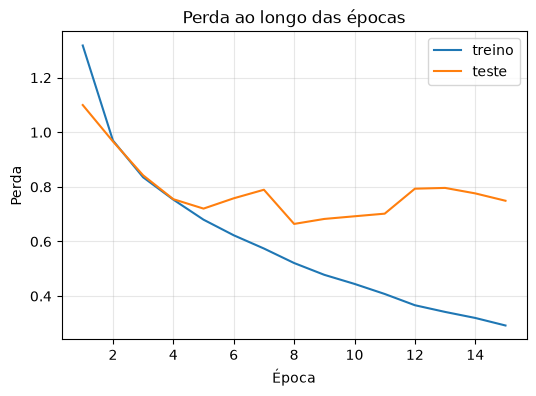

In [13]:
epocas = range(1, epochs + 1)
acc_teste_final = 100 * acc_test_hist[-1]

plt.figure(figsize=(6, 4))
plt.plot(epocas, loss_train_hist, label="treino")
plt.plot(epocas, loss_test_hist, label="teste")
plt.xlabel("Época")
plt.ylabel("Perda")
plt.title("Perda ao longo das épocas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Gera o Gráfico de Acurácia por Época e Acurácia Final de Teste

Acurácia final no conjunto de teste: 77.8%


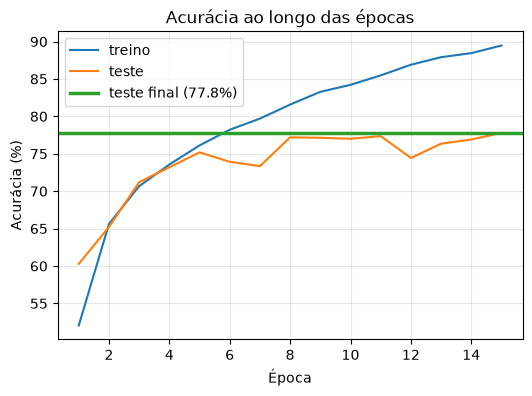

In [14]:
print(f"Acurácia final no conjunto de teste: {100 * acc_test_hist[-1]:.1f}%")

plt.figure(figsize=(6, 4))
plt.plot(epocas, [100 * a for a in acc_train_hist], label="treino")
plt.plot(epocas, [100 * a for a in acc_test_hist], label="teste")
plt.axhline(acc_teste_final, color="tab:green", linewidth=2.5, label=f"teste final ({acc_teste_final:.1f}%)")
plt.xlabel("Época")
plt.ylabel("Acurácia (%)")
plt.title("Acurácia ao longo das épocas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()